# Import statements

In [1]:
import pandas as pd
import numpy as np
import sklearn
import tensorflow as tf
import tqdm as notebook_tqdm
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.layers import BatchNormalization
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
#import shap
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
from tensorflow.keras.activations import gelu
from tensorflow.keras.regularizers import l2

In [2]:
print(np.__version__)

1.26.3


In [3]:
print(np.__file__)

/home/supadhyaya/.local/lib/python3.10/site-packages/numpy/__init__.py


In [4]:
print("GPUs available:", tf.config.list_physical_devices('GPU'))

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Load datasets

In [2]:
snp = pd.read_pickle("../genotype/lasso_yield_training_data.pkl")
snp.head()

,Gm01_553130,Gm01_1381480,Gm01_2192076,Gm01_5587600,Gm01_52160270,Gm01_52550007,Gm02_4127941,Gm02_12591363,Gm02_16551971,Gm03_1832951,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,2,0,0,2,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.54
AB-02_SOYBEAN.EVALUATION.MS2001_02,0,0,2,0,0,2,0,0,0,2,...,0,0,1,0,0,0,0,0,0,1.30
BR-01_SOYBEAN.EVALUATION.MS2011_12,2,0,0,2,0,0,0,0,2,0,...,0,0,0,0,1,0,0,0,0,4.33
BR-13_SOYBEAN.EVALUATION.MS2011_12,2,0,0,2,0,0,0,0,2,2,...,0,0,0,0,1,0,0,0,0,4.15
BR-14_SOYBEAN.EVALUATION.MS2011_12,2,0,2,2,0,0,0,0,2,2,...,0,0,0,0,1,0,0,0,0,2.87


In [3]:
snp['Data-storage-ID'] = snp.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
snp = snp.reset_index(drop=True).set_index('Data-storage-ID')
snp.head()

,Gm01_553130,Gm01_1381480,Gm01_2192076,Gm01_5587600,Gm01_52160270,Gm01_52550007,Gm02_4127941,Gm02_12591363,Gm02_16551971,Gm03_1832951,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,2,0,0,2,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.54
AB-02,0,0,2,0,0,2,0,0,0,2,...,0,0,1,0,0,0,0,0,0,1.30
BR-01,2,0,0,2,0,0,0,0,2,0,...,0,0,0,0,1,0,0,0,0,4.33
BR-13,2,0,0,2,0,0,0,0,2,2,...,0,0,0,0,1,0,0,0,0,4.15
BR-14,2,0,2,2,0,0,0,0,2,2,...,0,0,0,0,1,0,0,0,0,2.87


In [4]:
snp1 = snp.iloc[:, 0:175]
snp1.head()

,Gm01_553130,Gm01_1381480,Gm01_2192076,Gm01_5587600,Gm01_52160270,Gm01_52550007,Gm02_4127941,Gm02_12591363,Gm02_16551971,Gm03_1832951,...,Gm20_38359909,Gm20_38374128,Gm20_39043957,Gm20_40705319,Gm20_40809945,Gm20_40943142,Gm20_41225113,Gm20_41870782,Gm20_43852943,Gm20_48338157
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,2,0,0,2,0,2,0,0,0,0,...,2,2,0,0,0,0,0,2,1,0
AB-02,0,0,2,0,0,2,0,0,0,2,...,0,0,0,2,2,2,2,0,2,2
BR-01,2,0,0,2,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
BR-13,2,0,0,2,0,0,0,0,2,2,...,0,0,0,0,0,0,0,2,2,0
BR-14,2,0,2,2,0,0,0,0,2,2,...,2,2,0,0,0,0,0,0,0,0


In [5]:
y1 = snp["observation_value"]
y1.head()

Data-storage-ID
AB-01    1.54
AB-02    1.30
BR-01    4.33
BR-13    4.15
BR-14    2.87
Name: observation_value, dtype: float64

In [6]:
cov = snp.iloc[:,-32:]
cov.head()
## remove targte from this

,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,SOYBEAN.EVALUATION.3IL83.1,SOYBEAN.EVALUATION.3IL83.2,SOYBEAN.EVALUATION.3IL84,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.54
AB-02,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1.30
BR-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,4.33
BR-13,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,4.15
BR-14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,2.87


In [7]:
cov = cov.drop(columns=['observation_value'])

In [8]:
cov.head()

,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,SOYBEAN.EVALUATION.3IL83.1,SOYBEAN.EVALUATION.3IL83.2,SOYBEAN.EVALUATION.3IL84,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
BR-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
BR-13,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
BR-14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [9]:
y_final = snp["observation_value"]
y_final.head()

Data-storage-ID
AB-01    1.54
AB-02    1.30
BR-01    4.33
BR-13    4.15
BR-14    2.87
Name: observation_value, dtype: float64

In [10]:
pav = pd.read_pickle("../genotype/gene_pav_afterFS_varthreshold_yield_training_data.pkl")
pav.head()

,Data-storage-ID,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,AB-01,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.54
AB-02_SOYBEAN.EVALUATION.MS2001_02,AB-02,1,0,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,1.30
BR-01_SOYBEAN.EVALUATION.MS2011_12,BR-01,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.33
BR-13_SOYBEAN.EVALUATION.MS2011_12,BR-13,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.15
BR-14_SOYBEAN.EVALUATION.MS2011_12,BR-14,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,2.87


In [11]:
pav['Data-storage-ID'] = pav.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pav = pav.reset_index(drop=True).set_index('Data-storage-ID')
pav.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.54
AB-02,1,0,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,1.30
BR-01,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.33
BR-13,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.15
BR-14,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,2.87


In [12]:
pav1 = pav.iloc[:, 0:2918]
pav1.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,UWASoyPan05256,UWASoyPan05261,UWASoyPan05301,UWASoyPan05306,UWASoyPan05309,UWASoyPan05310,UWASoyPan05311,UWASoyPan05312,UWASoyPan05313,UWASoyPan05314
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,1,1,1,1,1,1,1,1,...,0,0,1,1,1,1,0,0,1,0
AB-02,1,0,1,1,1,1,1,1,1,1,...,1,0,1,1,0,1,0,1,1,0
BR-01,1,1,1,1,1,1,1,1,1,1,...,1,0,1,1,0,1,0,1,0,0
BR-13,1,1,1,1,1,1,1,1,1,1,...,1,0,1,1,0,1,0,1,0,0
BR-14,1,1,1,1,1,1,1,1,1,1,...,0,0,1,1,1,1,0,1,0,0


In [13]:
y2 = pav["observation_value"]
y2.head()

Data-storage-ID
AB-01    1.54
AB-02    1.30
BR-01    4.33
BR-13    4.15
BR-14    2.87
Name: observation_value, dtype: float64

In [14]:
pfam = pd.read_pickle("../genotype/pfam_pav_newIDs_eval5_varthreshold_yield_training_data.pkl")
pfam.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
HNSM-03_SOYBEAN.EVALUATION.2KY81,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.50
USB-127_SOYBEAN.EVALUATION.MS1999_01,0,0,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,2.47
USB-475_SOYBEAN.EVALUATION.1IL66,0,0,1,0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.65
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.12
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,1.06


In [15]:
pfam['Data-storage-ID'] = pfam.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pfam = pfam.reset_index(drop=True).set_index('Data-storage-ID')
pfam.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HNSM-03,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.50
USB-127,0,0,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,2.47
USB-475,0,0,1,0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.65
SRR1533290,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.12
SRR1533220,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,1.06


In [16]:
pfam1 = pfam.iloc[:, 0:1196]
pfam1.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,PF00069_UWASoyPan05055,PF07651_UWASoyPan05083,PF01541_UWASoyPan05113,PF07014_UWASoyPan05162,PF03140_UWASoyPan05171,PF06026_UWASoyPan05196,PF00232_UWASoyPan05231,PF07651_UWASoyPan05301,PF01657_UWASoyPan05311,PF00931_UWASoyPan05312
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HNSM-03,1,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,1,1,0,1
USB-127,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,1,1,0,0
USB-475,0,0,1,0,0,1,1,1,1,1,...,0,0,0,0,0,0,1,1,0,0
SRR1533290,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,1,0,0
SRR1533220,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,1,1,0,0


In [17]:
y3 = pfam["observation_value"]
y3.head()

Data-storage-ID
HNSM-03       1.50
USB-127       2.47
USB-475       2.65
SRR1533290    2.12
SRR1533220    1.06
Name: observation_value, dtype: float64

In [18]:
X1 = snp1.values
X2 = pav1.values
X3 = pfam1.values
X4 = cov.values
y1 = y1.values
y2 = y2.values
y3 = y3.values
y_final = y_final.values

In [19]:
print(X1.shape, X2.shape, X3.shape, X4.shape)

(803, 175) (803, 2918) (803, 1196) (803, 31)


# Build model

In [20]:
#3 input model

num_features_1 = 175  # placeholder value
num_features_2 = 2918
num_features_3 = 1196 

#Input layers
input_1 = Input(shape=(num_features_1,), name="input_1")
input_2 = Input(shape=(num_features_2,), name="input_2")
input_3 = Input(shape=(num_features_3,), name="input_3")

# Branch 1 
x1 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_1)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.3)(x1)
x1 = Dense(64, activation='relu')(x1)
branch_out1 = Dense(1, activation='linear', name="branch_output_1")(x1)  # intermediate output

# Branch 2
x2 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_2)
x2 = BatchNormalization()(x2)
x2 = Dropout(0.3)(x2)
x2 = Dense(64, activation='relu')(x2)
branch_out2 = Dense(1, activation='linear', name="branch_output_2")(x2)  # intermediate output

# Branch 3 
x3 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_3)
x3 = BatchNormalization()(x3)
x3 = Dropout(0.3)(x3)
x3 = Dense(64, activation='relu')(x3)
branch_out3 = Dense(1, activation='linear', name="branch_output_3")(x3)  # intermediate output

# Concatenate all branches
merged = Concatenate()([x1, x2, x3])

# --- Final combined layers ---
z = Dense(64, activation='relu')(merged)
z = BatchNormalization()(z)
z = Dropout(0.3)(z)
final_output = Dense(1, activation='linear', name="final_output")(z)

# Build the model 
model = Model(
    inputs=[input_1, input_2, input_3],
    outputs=[branch_out1, branch_out2, branch_out3, final_output],
    name="multi_input_multi_output_model"
)

In [55]:
# 4 input model
num_features_1 = 175  #change accordingly
num_features_2 = 2918
num_features_3 = 1196
num_features_4 = 31

# Input layers 
input_1 = Input(shape=(num_features_1,), name="input_1")
input_2 = Input(shape=(num_features_2,), name="input_2")
input_3 = Input(shape=(num_features_3,), name="input_3")
input_4 = Input(shape=(num_features_4,), name="input_4")

# Branch 1
x1 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_1)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.3)(x1)
x1 = Dense(64, activation='relu')(x1)
branch_out1 = Dense(1, activation='linear', name="branch_output_1")(x1)  # intermediate output

# Branch 2
x2 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_2)
x2 = BatchNormalization()(x2)
x2 = Dropout(0.3)(x2)
x2 = Dense(64, activation='relu')(x2)
branch_out2 = Dense(1, activation='linear', name="branch_output_2")(x2)  # intermediate output

# Branch 3 
x3 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_3)
x3 = BatchNormalization()(x3)
x3 = Dropout(0.3)(x3)
x3 = Dense(64, activation='relu')(x3)
branch_out3 = Dense(1, activation='linear', name="branch_output_3")(x3)  # intermediate output

# Concatenate all branches
merged = Concatenate()([x1, x2, x3, input_4])

# Final combined layers
z = Dense(64, activation='relu')(merged)
z = BatchNormalization()(z)
z = Dropout(0.3)(z)
final_output = Dense(1, activation='linear', name="final_output")(z)

# Build the model
model = Model(
    inputs=[input_1, input_2, input_3, input_4],
    outputs=[branch_out1, branch_out2, branch_out3, final_output],
    name="multi_input_multi_output_model"
)

In [21]:
model.summary()

Model: "multi_input_multi_output_model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 175)]                0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 2918)]               0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 1196)]               0         []                            
                                                                                                  
 dense (Dense)               (None, 128)                  22528     ['input_1[0][0]']             
                                                                     

In [56]:

#  Compile the model
model.compile(
    optimizer='adam',
    loss={
        "branch_output_1": "mse",
        "branch_output_2": "mse",
        "branch_output_3": "mse",
        "final_output": "mse"
    },
    metrics=['mae']
)

In [27]:
#DO NOT DO THIS
model.compile(
    optimizer='adam',
    loss={
        'branch_output_1': 'mse',
        'branch_output_2': 'mse',
        'branch_output_3': 'mse',
        'final_output': 'mse'
    },
    loss_weights={
        'branch_output_1': 0.2,
        'branch_output_2': 0.2,
        'branch_output_3': 0.2,
        'final_output': 1.0
    },
     metrics={
        'branch_output_1': ['mae'],
        'branch_output_2': ['mae'],
        'branch_output_3': ['mae'],
        'final_output':   ['mae']
    }
)

In [57]:
for i, X in enumerate([X1, X2, X3, X4], start=1):
    print(f"X{i} dtype:", getattr(X, "dtype", "no dtype"))
    print(f"X{i} sample:", X[:2])

for i, y in enumerate([y1, y2, y3, y_final], start=1):
    print(f"y{i} dtype:", getattr(y, "dtype", "no dtype"))
    print(f"y{i} sample:", y[:5])

X1 dtype: float32
X1 sample: [[2. 0. 0. 2. 0. 2. 0. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 2. 0. 0.
  0. 1. 1. 0. 2. 0. 1. 2. 0. 2. 1. 0. 0. 2. 2. 2. 0. 2. 1. 0. 0. 0. 0. 0.
  2. 0. 0. 2. 2. 0. 2. 0. 0. 2. 0. 1. 2. 0. 2. 2. 0. 0. 0. 0. 2. 0. 0. 0.
  0. 0. 2. 0. 0. 2. 2. 0. 0. 0. 2. 2. 0. 2. 1. 0. 0. 0. 0. 2. 2. 0. 0. 0.
  2. 0. 0. 2. 0. 2. 0. 0. 0. 2. 2. 2. 1. 0. 0. 2. 0. 2. 2. 0. 0. 2. 0. 2.
  2. 0. 0. 2. 0. 2. 0. 2. 2. 2. 0. 2. 2. 0. 0. 2. 2. 2. 2. 0. 2. 0. 0. 0.
  0. 2. 0. 2. 0. 0. 0. 0. 0. 0. 0. 2. 2. 1. 2. 0. 0. 0. 0. 0. 2. 2. 2. 0.
  0. 0. 0. 0. 2. 1. 0.]
 [0. 0. 2. 0. 0. 2. 0. 0. 0. 2. 2. 2. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 2. 0.
  2. 0. 2. 0. 0. 2. 0. 2. 2. 2. 2. 2. 2. 0. 2. 0. 0. 2. 0. 0. 0. 0. 2. 2.
  0. 0. 2. 0. 0. 2. 0. 2. 2. 2. 0. 0. 0. 0. 0. 2. 2. 0. 0. 2. 0. 2. 0. 0.
  0. 0. 0. 2. 2. 0. 0. 2. 0. 0. 0. 2. 0. 2. 2. 0. 2. 2. 0. 0. 0. 2. 2. 2.
  1. 0. 2. 2. 0. 2. 0. 0. 2. 2. 0. 2. 2. 2. 2. 2. 0. 2. 2. 2. 0. 0. 0. 0.
  2. 2. 0. 0. 0. 2. 2. 0. 0. 2. 2. 2. 2. 2. 2. 0. 2. 2. 2. 

In [58]:
X1 = np.asarray(X1, dtype=np.float32)
X2 = np.asarray(X2, dtype=np.float32)
X3 = np.asarray(X3, dtype=np.float32)
X4 = np.asarray(X4, dtype=np.float32)

y1 = np.asarray(y1, dtype=np.float32)
y2 = np.asarray(y2, dtype=np.float32)
y3 = np.asarray(y3, dtype=np.float32)
y_final = np.asarray(y_final, dtype=np.float32)

In [59]:
# training all models

In [60]:
# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',    # Stop based on validation loss
    patience=10,           # Wait 10 epochs for improvement
    restore_best_weights=True  # Restore weights from the best epoch
)

In [61]:
# Model checkpoint callback
checkpoint = ModelCheckpoint(
    "best_model_vt_withenv1.h5",       # Filepath to save the model
    monitor='val_loss',    # Save based on validation loss
    save_best_only=True,   # Only save the best model
    save_weights_only=False  # Save the entire model (architecture + weights)
)

In [33]:
#do only if necessary
lr_reduction = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=20
    )

In [89]:
#history = model.fit( [X1, X2, X3], [y1, y2, y3, y_final], 
                     epochs=100, batch_size=32, validation_split=0.2, verbose=0,
                   callbacks=[early_stop, checkpoint, lr_reduction])

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 3)

In [62]:
history = model.fit( [X1, X2, X3, X4], [y1, y2, y3, y_final], 
                     epochs=100, batch_size=32, validation_split=0.1, verbose=0,
                   callbacks=[early_stop, checkpoint])

/usr/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


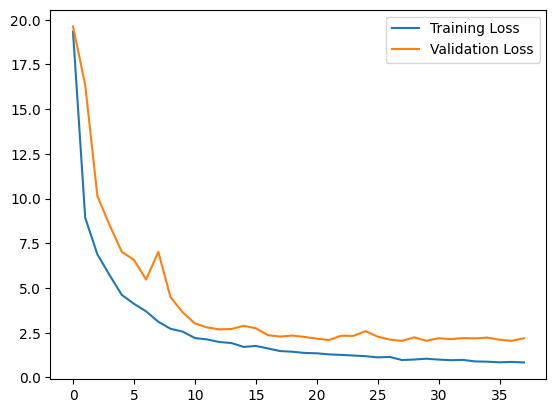

In [92]:
#for new model
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.savefig("loss_curve_yield_vt_withenv.png", dpi=600, bbox_inches="tight")
plt.show()

In [176]:
model.save("new_model.h5")

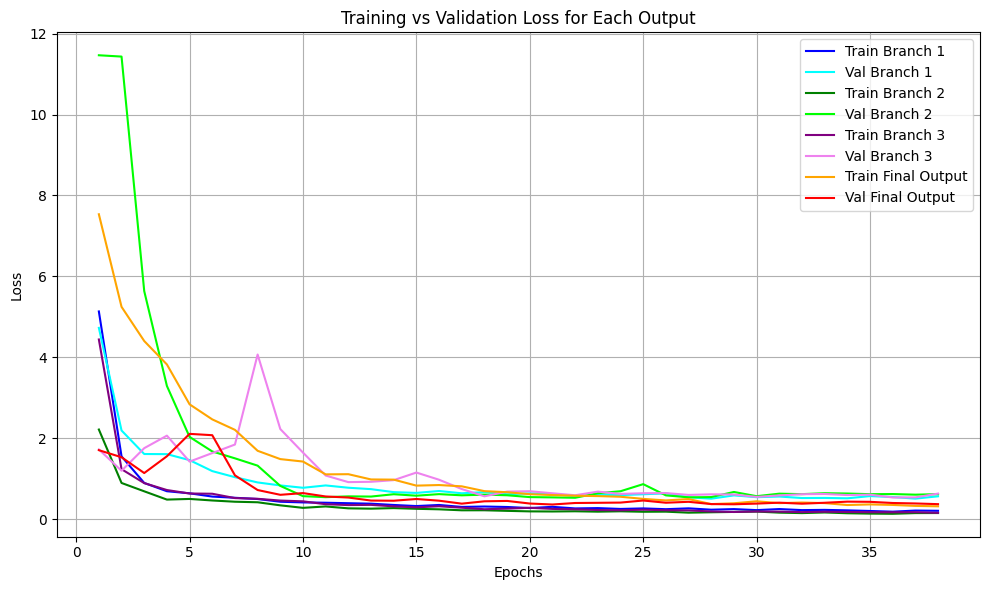

In [91]:

epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(10, 6))

# Branch 1
plt.plot(epochs, history.history['branch_output_1_loss'], label='Train Branch 1', color='blue')
plt.plot(epochs, history.history['val_branch_output_1_loss'], label='Val Branch 1', color='cyan')

# Branch 2
plt.plot(epochs, history.history['branch_output_2_loss'], label='Train Branch 2', color='green')
plt.plot(epochs, history.history['val_branch_output_2_loss'], label='Val Branch 2', color='lime')

# Branch 3
plt.plot(epochs, history.history['branch_output_3_loss'], label='Train Branch 3', color='purple')
plt.plot(epochs, history.history['val_branch_output_3_loss'], label='Val Branch 3', color='violet')

# Final Output
plt.plot(epochs, history.history['final_output_loss'], label='Train Final Output', color='orange')
plt.plot(epochs, history.history['val_final_output_loss'], label='Val Final Output', color='red')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss for Each Output')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("perbranch_curve_yield_vt_withenv.png", dpi=600, bbox_inches="tight")
plt.show()

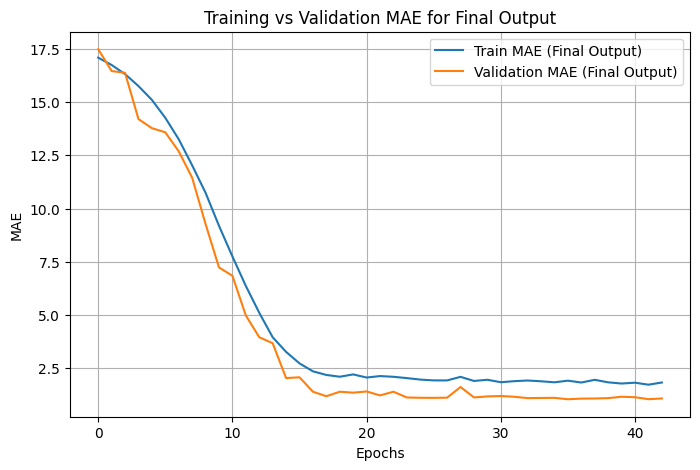

In [88]:
#for new model
plt.figure(figsize=(8, 5))

plt.plot(history.history['final_output_mae'], label='Train MAE (Final Output)')
plt.plot(history.history['val_final_output_mae'], label='Validation MAE (Final Output)')

plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE for Final Output')
plt.legend()
plt.grid(True)
plt.show()

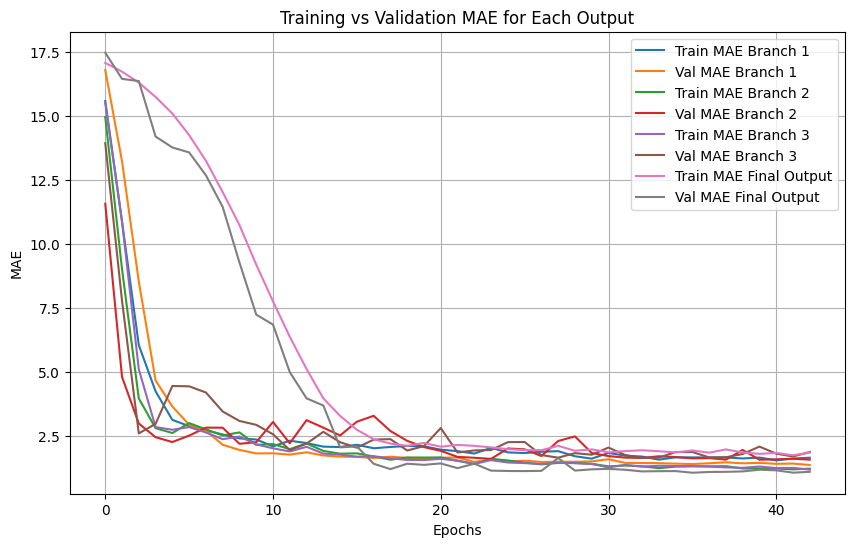

In [89]:
plt.figure(figsize=(10, 6))

# Branch 1
plt.plot(history.history['branch_output_1_mae'], label='Train MAE Branch 1')
plt.plot(history.history['val_branch_output_1_mae'], label='Val MAE Branch 1')

# Branch 2
plt.plot(history.history['branch_output_2_mae'], label='Train MAE Branch 2')
plt.plot(history.history['val_branch_output_2_mae'], label='Val MAE Branch 2')

# Branch 3
plt.plot(history.history['branch_output_3_mae'], label='Train MAE Branch 3')
plt.plot(history.history['val_branch_output_3_mae'], label='Val MAE Branch 3')

# Final Output
plt.plot(history.history['final_output_mae'], label='Train MAE Final Output')
plt.plot(history.history['val_final_output_mae'], label='Val MAE Final Output')

plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE for Each Output')
plt.legend()
plt.grid(True)
plt.show()

# Testing

In [64]:
holdout = pd.read_pickle("../genotype/yield_holdout_data.pkl")

In [65]:
holdout.head()

,Data-storage-ID,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
ESS_SOYBEAN.EVALUATION.MS1999_01,ESS,1,0,0,0,0,1,1,0,0,...,1,0,0,0,0,0,0,0,0,3.60
HN012_SOYBEAN.EVALUATION.IL945,HN012,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.86
HN018_SOYBEAN.EVALUATION.3IL83.2,HN018,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.87
HN037_SOYBEAN.EVALUATION.1IL64,HN037,0,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1.88
HN060_SOYBEAN.EVALUATION.4IL87,HN060,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,2.02


In [66]:
snp_holdout = holdout[snp1.columns]

In [67]:
snp_holdout['Data-storage-ID'] = snp_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
snp_holdout = snp_holdout.reset_index(drop=True).set_index('Data-storage-ID')
snp_holdout.head()

/tmp/ipykernel_2446923/3552470459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snp_holdout['Data-storage-ID'] = snp_holdout.index.to_series().str.split('_').str[0]


,Gm01_553130,Gm01_1381480,Gm01_2192076,Gm01_5587600,Gm01_52160270,Gm01_52550007,Gm02_4127941,Gm02_12591363,Gm02_16551971,Gm03_1832951,...,Gm20_38359909,Gm20_38374128,Gm20_39043957,Gm20_40705319,Gm20_40809945,Gm20_40943142,Gm20_41225113,Gm20_41870782,Gm20_43852943,Gm20_48338157
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,2,0,2,0,0,0,0,2,1,...,1,1,0,0,0,0,0,0,0,2
HN012,2,0,2,0,2,2,0,0,0,0,...,2,2,0,0,0,0,0,0,0,0
HN018,0,0,2,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN037,0,2,0,0,0,0,2,2,2,2,...,2,2,2,2,2,2,2,0,2,0
HN060,2,0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [68]:
snp_holdout.head()

,Gm01_553130,Gm01_1381480,Gm01_2192076,Gm01_5587600,Gm01_52160270,Gm01_52550007,Gm02_4127941,Gm02_12591363,Gm02_16551971,Gm03_1832951,...,Gm20_38359909,Gm20_38374128,Gm20_39043957,Gm20_40705319,Gm20_40809945,Gm20_40943142,Gm20_41225113,Gm20_41870782,Gm20_43852943,Gm20_48338157
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,2,0,2,0,0,0,0,2,1,...,1,1,0,0,0,0,0,0,0,2
HN012,2,0,2,0,2,2,0,0,0,0,...,2,2,0,0,0,0,0,0,0,0
HN018,0,0,2,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN037,0,2,0,0,0,0,2,2,2,2,...,2,2,2,2,2,2,2,0,2,0
HN060,2,0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [69]:
holdout = pd.read_pickle("../genotype/gene_pav_afterFS_varthreshold_yield_holdout_data_pav.pkl")

In [70]:
pav_holdout = holdout[pav1.columns]

In [71]:
pav_holdout['Data-storage-ID'] = pav_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pav_holdout = pav_holdout.reset_index(drop=True).set_index('Data-storage-ID')
pav_holdout.head()

/tmp/ipykernel_2446923/2899270742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pav_holdout['Data-storage-ID'] = pav_holdout.index.to_series().str.split('_').str[0]


,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,UWASoyPan05256,UWASoyPan05261,UWASoyPan05301,UWASoyPan05306,UWASoyPan05309,UWASoyPan05310,UWASoyPan05311,UWASoyPan05312,UWASoyPan05313,UWASoyPan05314
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,1,1,1,1,1,0,0,1,1,...,1,0,1,1,0,1,1,1,0,0
HN012,1,0,1,1,1,1,1,1,0,1,...,1,0,0,0,0,1,0,0,0,0
HN018,1,0,1,0,1,1,1,1,0,1,...,1,0,0,1,1,1,0,0,0,0
HN037,1,0,1,1,1,1,1,1,1,1,...,0,1,1,1,0,1,0,1,0,0
HN060,1,0,1,1,1,1,1,1,1,1,...,0,0,0,1,1,1,0,0,0,1


In [72]:
pav_holdout.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,UWASoyPan05256,UWASoyPan05261,UWASoyPan05301,UWASoyPan05306,UWASoyPan05309,UWASoyPan05310,UWASoyPan05311,UWASoyPan05312,UWASoyPan05313,UWASoyPan05314
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,1,1,1,1,1,0,0,1,1,...,1,0,1,1,0,1,1,1,0,0
HN012,1,0,1,1,1,1,1,1,0,1,...,1,0,0,0,0,1,0,0,0,0
HN018,1,0,1,0,1,1,1,1,0,1,...,1,0,0,1,1,1,0,0,0,0
HN037,1,0,1,1,1,1,1,1,1,1,...,0,1,1,1,0,1,0,1,0,0
HN060,1,0,1,1,1,1,1,1,1,1,...,0,0,0,1,1,1,0,0,0,1


In [73]:
holdout = pd.read_pickle("../genotype/pfam_pav_newIDs_eval5_varthreshold_yield_holdout_data_pav.pkl")

In [74]:
pfam_holdout = holdout[pfam1.columns]

In [75]:
pfam_holdout['Data-storage-ID'] = pfam_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pfam_holdout = pfam_holdout.reset_index(drop=True).set_index('Data-storage-ID')
pfam_holdout.head()

/tmp/ipykernel_2446923/577540637.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pfam_holdout['Data-storage-ID'] = pfam_holdout.index.to_series().str.split('_').str[0]


,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,PF00069_UWASoyPan05055,PF07651_UWASoyPan05083,PF01541_UWASoyPan05113,PF07014_UWASoyPan05162,PF03140_UWASoyPan05171,PF06026_UWASoyPan05196,PF00232_UWASoyPan05231,PF07651_UWASoyPan05301,PF01657_UWASoyPan05311,PF00931_UWASoyPan05312
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,1,1,0,0,1,1,1,1,1,...,0,1,0,1,0,0,1,1,1,1
HN012,0,0,1,1,1,1,1,1,1,1,...,1,0,0,0,0,1,1,0,0,0
HN018,0,0,0,1,1,1,1,1,1,1,...,1,0,0,0,0,0,1,0,0,0
HN037,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,1,1,0,1
HN060,0,0,1,1,1,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0


In [76]:
pfam_holdout.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,PF00069_UWASoyPan05055,PF07651_UWASoyPan05083,PF01541_UWASoyPan05113,PF07014_UWASoyPan05162,PF03140_UWASoyPan05171,PF06026_UWASoyPan05196,PF00232_UWASoyPan05231,PF07651_UWASoyPan05301,PF01657_UWASoyPan05311,PF00931_UWASoyPan05312
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,1,1,0,0,1,1,1,1,1,...,0,1,0,1,0,0,1,1,1,1
HN012,0,0,1,1,1,1,1,1,1,1,...,1,0,0,0,0,1,1,0,0,0
HN018,0,0,0,1,1,1,1,1,1,1,...,1,0,0,0,0,0,1,0,0,0
HN037,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,1,1,0,1
HN060,0,0,1,1,1,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0


In [77]:
cov_holdout = holdout[cov.columns]

In [78]:
cov_holdout.head()

,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,SOYBEAN.EVALUATION.3IL83.1,SOYBEAN.EVALUATION.3IL83.2,SOYBEAN.EVALUATION.3IL84,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
new_line,,,,,,,,,,,,,,,,,,,,,
ESS_SOYBEAN.EVALUATION.MS1999_01,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
HN012_SOYBEAN.EVALUATION.IL945,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN018_SOYBEAN.EVALUATION.3IL83.2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
HN037_SOYBEAN.EVALUATION.1IL64,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN060_SOYBEAN.EVALUATION.4IL87,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [79]:
cov_holdout['Data-storage-ID'] = cov_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
cov_holdout = cov_holdout.reset_index(drop=True).set_index('Data-storage-ID')
cov_holdout.head()

/tmp/ipykernel_2446923/403245011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cov_holdout['Data-storage-ID'] = cov_holdout.index.to_series().str.split('_').str[0]


,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,SOYBEAN.EVALUATION.3IL83.1,SOYBEAN.EVALUATION.3IL83.2,SOYBEAN.EVALUATION.3IL84,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
HN012,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN018,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
HN037,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN060,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [80]:
y1_test = holdout['observation_value'].values
y2_test = holdout['observation_value'].values
y3_test = holdout['observation_value'].values
y_final_test = holdout['observation_value'].values

In [81]:
y1_test

array([3.6 , 1.86, 1.87, 1.88, 2.02, 1.74, 2.05, 3.51, 3.32, 3.87, 1.98,
       2.01, 1.69, 2.61, 1.91, 3.71, 4.12, 1.61, 1.8 , 2.05, 2.88, 1.77,
       1.76, 2.21, 3.05, 1.91, 2.59, 0.99, 1.51, 2.55, 2.97, 1.93, 1.56,
       3.18, 2.78, 1.15, 2.57, 3.05, 2.14, 2.91, 3.15, 2.29, 1.28, 2.21,
       2.33, 0.74, 3.29, 2.66, 2.46, 1.01, 1.55, 2.2 , 1.03, 1.04, 1.02,
       1.9 , 2.88, 2.21, 1.57, 2.31, 0.78, 1.41, 1.42, 0.53, 2.21, 1.6 ,
       2.58, 3.36, 1.88, 2.61, 2.39, 2.45, 3.6 , 0.63, 1.32, 1.63, 1.61,
       2.16, 2.41, 2.04, 1.52, 2.63, 1.61, 2.93, 1.84, 1.4 , 2.18, 2.17,
       3.52, 4.52])

In [82]:
X1_test = snp_holdout.values
X2_test = pav_holdout.values
X3_test = pfam_holdout.values
X4_test = cov_holdout.values

In [40]:
#if not in the same sesion
model = load_model('pickle_models/best_model_vt2.h5')

In [49]:
model.summary()

Model: "multi_input_multi_output_model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 175)]                0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 2918)]               0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 1196)]               0         []                            
                                                                                                  
 dense (Dense)               (None, 128)                  22528     ['input_1[0][0]']             
                                                                     

In [83]:
print(X1_test.dtype, X2_test.dtype, X3_test.dtype, X4_test.dtype)

int64 object int64 int64


In [84]:
X1_test = X1_test.astype("float32")
X2_test = X2_test.astype("float32")
X3_test = X3_test.astype("float32")
X4_test = X4_test.astype("float32")

In [85]:
print(X1_test.shape)
print(X2_test.shape)
print(X3_test.shape)
print(X4_test.shape)

(90, 175)
(90, 2918)
(90, 1196)
(90, 31)


In [86]:
pred1, pred2, pred3, pred_final = model.predict(
    [X1_test, X2_test, X3_test, X4_test]
)

3/3 [==============================] - 0s 3ms/step


In [87]:
results = model.evaluate(
    [X1_test, X2_test, X3_test, X4_test],
    [y1_test, y2_test, y3_test, y_final_test],
    verbose=1
)

print(results)

3/3 [==============================] - 0s 9ms/step - loss: 1.9440 - branch_output_1_loss: 0.5492 - branch_output_2_loss: 0.5570 - branch_output_3_loss: 0.4643 - final_output_loss: 0.3673 - branch_output_1_mae: 0.5653 - branch_output_2_mae: 0.5642 - branch_output_3_mae: 0.5419 - final_output_mae: 0.4626
[1.944004774093628, 0.5491933226585388, 0.5569686889648438, 0.464316725730896, 0.3672598898410797, 0.5653318762779236, 0.5641850233078003, 0.5418832302093506, 0.4626163840293884]


In [88]:
# RMSE 
rmse_1 = np.sqrt(mean_squared_error(y1_test, pred1))
rmse_2 = np.sqrt(mean_squared_error(y2_test, pred2))
rmse_3 = np.sqrt(mean_squared_error(y3_test, pred3))
rmse_final = np.sqrt(mean_squared_error(y_final_test, pred_final))

# R²
r2_1 = r2_score(y1_test, pred1)
r2_2 = r2_score(y2_test, pred2)
r2_3 = r2_score(y3_test, pred3)
r2_final = r2_score(y_final_test, pred_final)

# Pearson r
pearson_1, pval_1 = pearsonr(y1_test.flatten(), pred1.flatten())
pearson_2, pval_2 = pearsonr(y2_test.flatten(), pred2.flatten())
pearson_3, pval_3 = pearsonr(y3_test.flatten(), pred3.flatten())
pearson_final, pval_final = pearsonr(y_final_test.flatten(), pred_final.flatten())

# Print everything nicely
print("\n===== PERFORMANCE METRICS =====")
print(f"Branch 1 – RMSE: {rmse_1:.4f}, R²: {r2_1:.4f}, Pearson r: {pearson_1:.4f} (p={pval_1:.2e})")
print(f"Branch 2 – RMSE: {rmse_2:.4f}, R²: {r2_2:.4f}, Pearson r: {pearson_2:.4f} (p={pval_2:.2e})")
print(f"Branch 3 – RMSE: {rmse_3:.4f}, R²: {r2_3:.4f}, Pearson r: {pearson_3:.4f} (p={pval_3:.2e})")
print(f"Final Output – RMSE: {rmse_final:.4f}, R²: {r2_final:.4f}, Pearson r: {pearson_final:.4f} (p={pval_final:.2e})")


===== PERFORMANCE METRICS =====
Branch 1 – RMSE: 0.7411, R²: 0.1762, Pearson r: 0.5525 (p=1.64e-08)
Branch 2 – RMSE: 0.7463, R²: 0.1645, Pearson r: 0.5243 (p=1.14e-07)
Branch 3 – RMSE: 0.6814, R²: 0.3035, Pearson r: 0.5835 (p=1.58e-09)
Final Output – RMSE: 0.6060, R²: 0.4491, Pearson r: 0.6809 (p=1.54e-13)


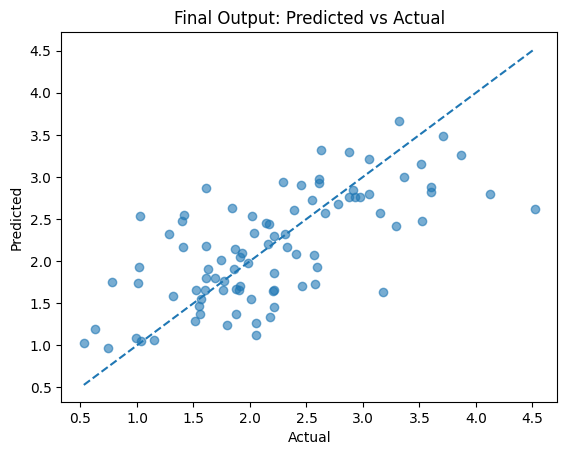

In [89]:
plt.scatter(y_final_test, pred_final, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Final Output: Predicted vs Actual")
plt.plot([y_final_test.min(), y_final_test.max()],
         [y_final_test.min(), y_final_test.max()],
         linestyle="--")   # 1:1 line
plt.savefig("predicted_actual_yeild_vt_withenv.png", dpi=600, bbox_inches="tight")
plt.show()

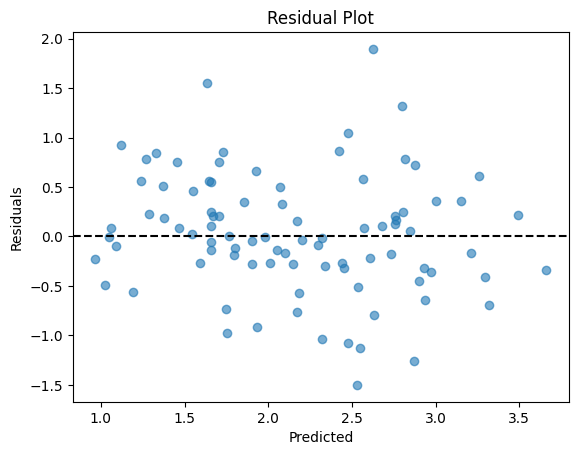

In [90]:
residuals = y_final_test - pred_final.reshape(-1)

plt.scatter(pred_final, residuals, alpha=0.6)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.savefig("residual_yield_vt_withenv.png", dpi=600, bbox_inches="tight")
plt.show()

# XAI (nope, didn't work)

In [68]:
background = [x[:100] for x in [X1, X2, X3, X4]]

In [80]:
for layer in model.layers:
    if "output" in layer.name:
        print(layer.name)


branch_output_1
branch_output_2
branch_output_3
final_output


In [74]:
# Branch 1 model
model_b1 = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer('branch_output_1').output)

# Branch 2 model
model_b2 = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer('branch_output_2').output)

# Branch 3 model
model_b3 = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer('branch_output_3').output)

# Final output model
model_final = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer('final_output').output)

In [75]:
test_data = [X1_test, X2_test, X3_test, X4_test]

expl_b1 = shap.DeepExplainer(model_b1, background)
expl_b2 = shap.DeepExplainer(model_b2, background)
expl_b3 = shap.DeepExplainer(model_b3, background)
expl_final = shap.DeepExplainer(model_final, background)

In [78]:
shap_b1 = expl_b1.shap_values(test_data)
shap_b2 = expl_b2.shap_values(test_data)
shap_b3 = expl_b3.shap_values(test_data)
shap_final = expl_final.shap_values(test_data)

AttributeError: 'NoneType' object has no attribute 'numpy'

In [81]:
import shap
import numpy as np

# Ensure float32 (DeepExplainer requires it)
X1_test = X1_test.astype("float32")
X2_test = X2_test.astype("float32")
X3_test = X3_test.astype("float32")
X4_test = X4_test.astype("float32")

X1_bg = X1[:100].astype("float32")
X2_bg = X2[:100].astype("float32")
X3_bg = X3[:100].astype("float32")
X4_bg = X4[:100].astype("float32")

background = [X1_bg, X2_bg, X3_bg, X4_bg]
test_data = [X1_test, X2_test, X3_test, X4_test]

# Build submodels
submodel_b1 = Model(inputs=model.inputs, outputs=model.outputs[0])
submodel_b2 = Model(inputs=model.inputs, outputs=model.outputs[1])
submodel_b3 = Model(inputs=model.inputs, outputs=model.outputs[2])
submodel_final = Model(inputs=model.inputs, outputs=model.outputs[3])

# Branch 1 SHAP
expl_b1 = shap.DeepExplainer(submodel_b1, background)
shap_b1 = expl_b1.shap_values(test_data)

# Branch 2 SHAP
expl_b2 = shap.DeepExplainer(submodel_b2, background)
shap_b2 = expl_b2.shap_values(test_data)

# Branch 3 SHAP
expl_b3 = shap.DeepExplainer(submodel_b3, background)
shap_b3 = expl_b3.shap_values(test_data)

# Final output SHAP
expl_final = shap.DeepExplainer(submodel_final, background)
shap_final = expl_final.shap_values(test_data)


AttributeError: 'NoneType' object has no attribute 'numpy'

In [77]:
shap.summary_plot(shap_b1[0], X1_test)

NameError: name 'shap_b1' is not defined

In [ ]:
shap.summary_plot(shap_values[3][2], X3_test, feature_names=X3_columns)

In [ ]:
shap.summary_plot(shap_values[3][3], X4_test, feature_names=X4_columns)